# Расчётно-графическая работа №1
**Описание выборки. Оценивание параметров.
Доверительные интервалы**

In [1]:
COLUMN = 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math

from sires.SortedSires import SortedSires
from sires.SiresInfo import SiresInfo

from hist.Histogram import Histogram
from hist.IntervalRules import IntervalRules

from distrib.DistribType import DistribType
from distrib.Estimation import Estimation
from distrib.DistribDencity import DistribDencity
from distrib.EstimatedParamsPlots import EstimatedParamsPlots
from distrib.ParametricProb import ParametricProb
from distrib.ConfidenceIntervals import ConfidenceIntervals

from utils.Reader import Reader

from func.EmpericalDistribFunc import EmpericalDistribFunc

Читаем данные из файла и подготавливаем всякое


In [3]:
file = Reader("../RGR1_A-8_X1-X4.csv")
sorted_data = SortedSires(file.read_column(COLUMN-1))
sires_info = SiresInfo(sorted_data)

## 1 Первичное описание выборки

### 1.1 Вариационный ряд

In [4]:
sorted_data

Вариационный ряд
   Всего эдементов: 200
   Первые 5 элементов: 19.34, 20.31, 20.72, 20.97, 21.09
   Последние 5 элементов: 451.74, 451.66, 437.48, 334.45, 331.58

### 1.2 Эмпирическая функция распределения

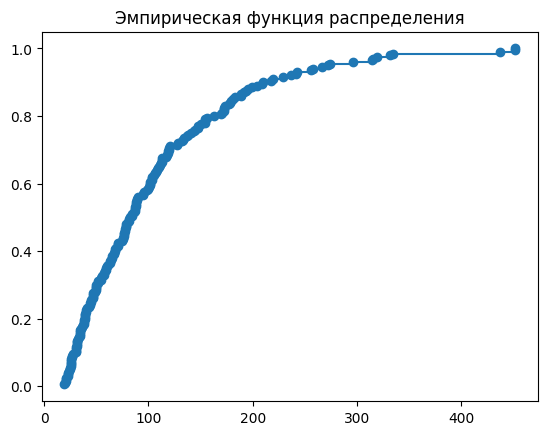

In [5]:
EmpericalDistribFunc(sorted_data).draw()
plt.show()

### 1.3 Построение гистограм

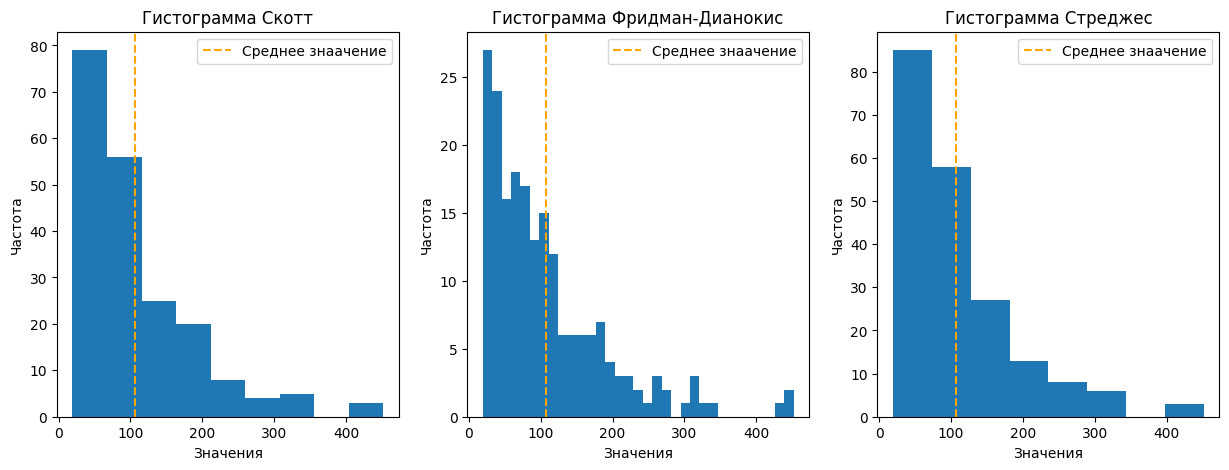

In [6]:
Histogram(sorted_data).draw_all()

### 1.4 Основные характеристики выборки

In [7]:
sires_info

Выборочные оценки:
    Среднее:                    x̄ = 106.745
    Медиана:                    x̃ =  83.280
    Размах:                     [19.3, 451.7]
    Дисперсия (смещённая):      S² =  6894.879
    Дисперсия (несмещённая):    σ² =  6929.526
    Ст. отклонение (смещ.):     S =  83.035
    Ст. отклонение (несмещ.):   σ =  83.244
    Квантиль 25%:               45.235
    Квантиль 50%:               83.280
    Квантиль 75%:               141.575

### Форма распределения

График распределения ассиметричен\
Есть небольшие выбросы\
Значения ограничены естественно

## 2 Предположение о виде закона распределения


Наблюдаемое распредение - **экспоненциальное**

Асимметрия графика свидетельствует о том, что значения концентрируются в левой части, а правый хвост постепенно спадает, что соответствует характерной форме экспоненциального распределения.\
Выбросы не противоречат общей картине

In [8]:
dist_type = DistribType.EXP

In [9]:
def show_estimation_results(dist_params, dist: DistribType) -> None:
    if dist == DistribType.NORMAL:
        print("\n=== Нормальное распределение ===")
        print(f"Метод моментов: â = {dist_params[0].a:.3f},   σ̂ = {math.sqrt(dist_params[0].sigma2):.3f}")
        print(f"ММП:            â = {dist_params[1].a:.3f},   σ̂ = {math.sqrt(dist_params[1].sigma2):.3f}")

    if dist == DistribType.UNIFORM:
        print("\n=== Равномерное распределение ===")
        print(f"Метод моментов: â = {dist_params[0].a:.3f},   b̂ = {dist_params[0].b:.3f}")
        print(f"ММП:            â = {dist_params[1].a:.3f},   b̂ = {dist_params[1].b:.3f}")

    if dist == DistribType.EXP:
        print("\n=== Экспоненциальное распределение ===")
        print(f"Метод моментов: λ̂ = {dist_params[0].l:.3f},   ĉ = {dist_params[0].c:.3f}")
        print(f"ММП:            λ̂ = {dist_params[1].l:.3f},   ĉ = {dist_params[1].c:.3f}")

dist_params = Estimation(sires_info, dist_type)()
show_estimation_results(dist_params, dist_type)


=== Экспоненциальное распределение ===
Метод моментов: λ̂ = 0.012,   ĉ = 23.710
ММП:            λ̂ = 0.011,   ĉ = 19.340


*Графики плотностей*

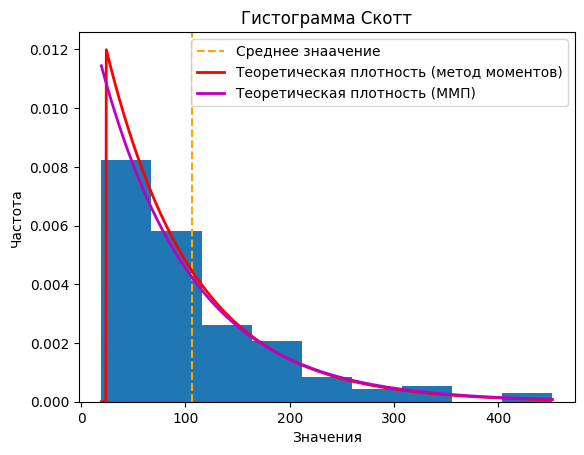

In [ ]:
Histogram(sorted_data, True).draw(IntervalRules.SCOTT)

x_range = np.linspace(sorted_data.get_min(), sorted_data.get_max(), 1000)

dencity = DistribDencity(dist_params[0], dist_type).get_dencity()
y_range = [dencity(x) for x in x_range]
plt.plot(x_range, y_range, 'r-', linewidth=2, label='Теоретическая плотность (метод моментов)')

dencity = DistribDencity(dist_params[1], dist_type).get_dencity()
y_range = [dencity(x) for x in x_range]
plt.plot(x_range, y_range, 'm-', linewidth=2, label='Теоретическая плотность (ММП)')

plt.legend()
plt.show()

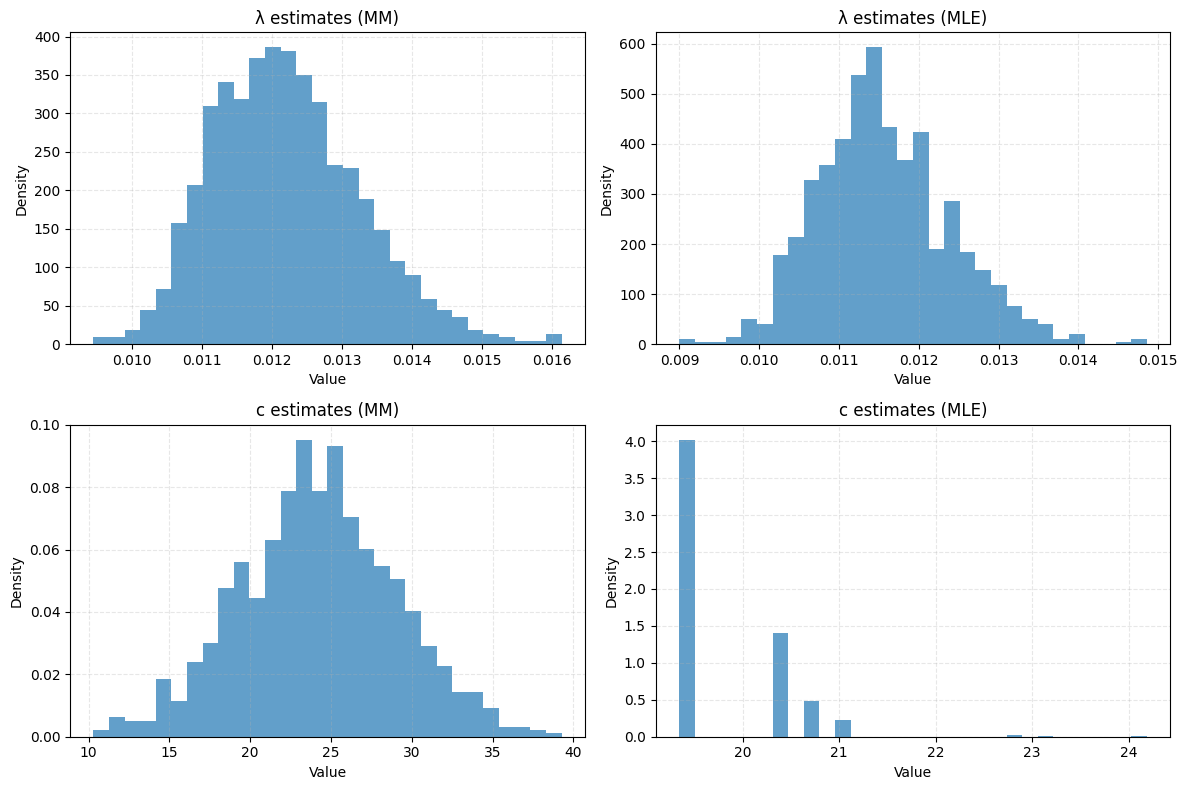

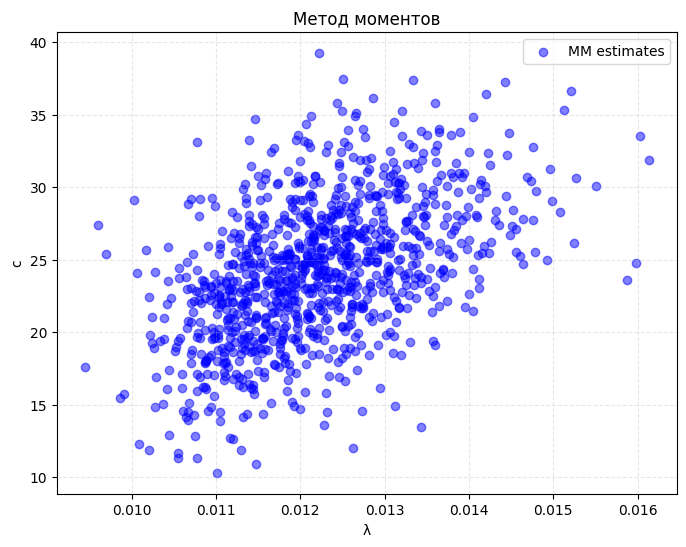

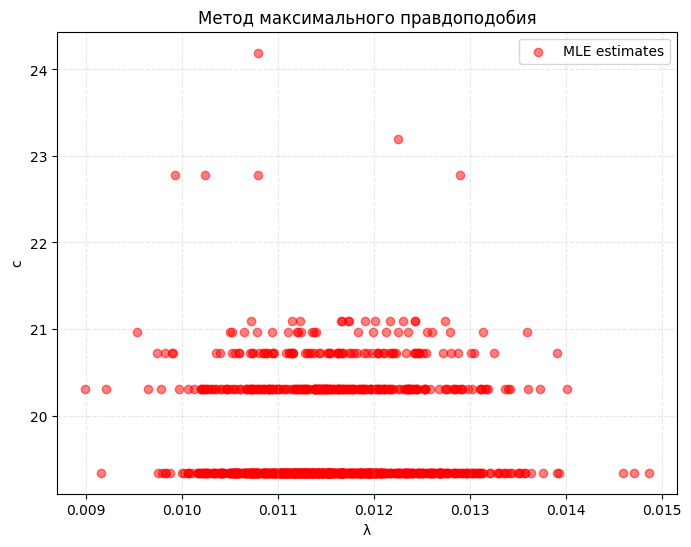

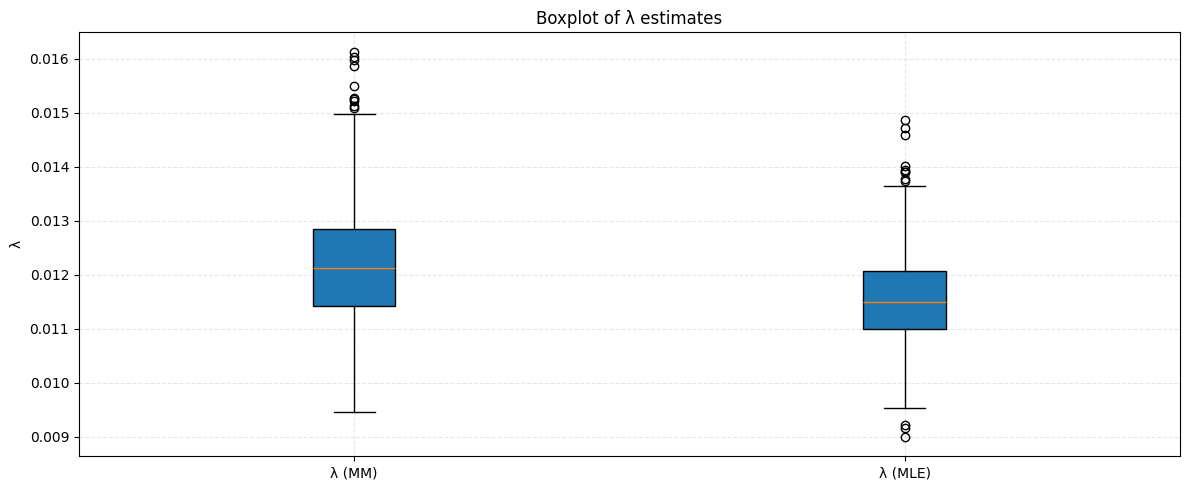

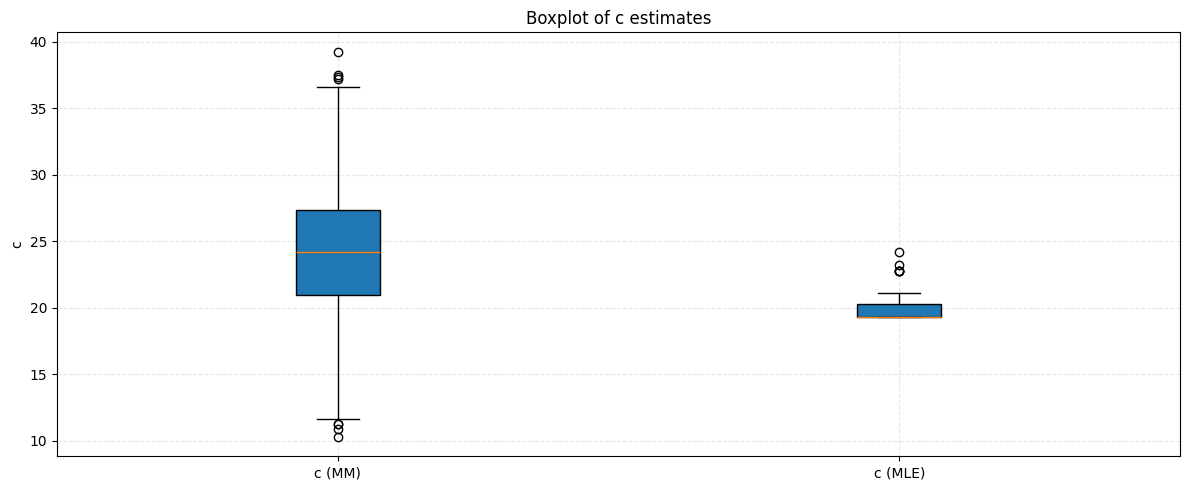

In [11]:
EstimatedParamsPlots(sorted_data, dist_type).draw()

## 4 Оценивание параметрической вероятности двумя способами

In [12]:
result = ParametricProb(sorted_data, dist_type)()
print(f"Эмпирическая оценка P(X > x0):     {result[0]:.3f}")
print(f"Параметрическая оценка P(X > x0):  {result[1]:.3f}")

Эмпирическая оценка P(X > x0):     0.135
Параметрическая оценка P(X > x0):  0.142


## 5. Оценка моментов по сгруппированной выборке

In [13]:
def grouped_moments(data: list[float], bins: int):
    n = len(data)
    counts, bin_edges = np.histogram(data, bins=bins)
    midpoints = (bin_edges[:-1] + bin_edges[1:]) / 2
    mean_grouped = np.sum(counts * midpoints) / n
    var_grouped = np.sum(counts * (midpoints - mean_grouped)**2) / (n - 1)

    return mean_grouped, var_grouped

mean_grouped, s2_grouped = grouped_moments([i for i in sorted_data], bins=7)


print("=== По исходным данным ===")
print(f"Среднее:                        {sires_info.mean:.3f}")
print(f"Дисперсия (несмещённая):        {sires_info.s2:.3f}")

print("\n=== По сгруппированной выборке ===")
print(f"Среднее:                        {mean_grouped:.3f}")
print(f"Дисперсия (несмещённая):        {s2_grouped:.3f}")

print("\n=== Абсолютные Погрешности ===")
print(f"Среднее:                        {abs(sires_info.mean - mean_grouped):.3f}")
print(f"Дисперсия (несмещённая):        {abs(sires_info.s2 - s2_grouped):.3f}")

print("\n=== Относительные Погрешности ===")
print(f"Среднее:                        {abs(sires_info.mean - mean_grouped)/sires_info.mean:.3f}")
print(f"Дисперсия (несмещённая):        {abs(sires_info.s2 - s2_grouped)/sires_info.s2:.3f}")

=== По исходным данным ===
Среднее:                        106.745
Дисперсия (несмещённая):        6929.526

=== По сгруппированной выборке ===
Среднее:                        110.144
Дисперсия (несмещённая):        6324.107

=== Абсолютные Погрешности ===
Среднее:                        3.399
Дисперсия (несмещённая):        605.419

=== Относительные Погрешности ===
Среднее:                        0.032
Дисперсия (несмещённая):        0.087


## 6. Доверительные интервалы

In [14]:
_ = ConfidenceIntervals(sires_info).CPT()

print("\n=== EX по ЦПТ ===")
print(f"[{_[0]:.3f}; {_[1]:.3f}]")

if dist_type == DistribType.NORMAL:
    _ = ConfidenceIntervals(sires_info).uniform_exact()

    print("\n=== Точный μ для нормального распределения ===")
    print(f"[{_[0][0]:.3f}; {_[0][1]:.3f}]")
    print("\n=== Точный σ² для нормального распределения ===")
    print(f"[{_[1][0]:.3f}; {_[1][1]:.3f}]")


=== EX по ЦПТ ===
[95.208; 118.282]
